# VGG11 and ResNet18 on Tiny ImageNet-200

This notebook implements and compares two convolutional neural network architectures — **VGG11** and **ResNet18** — trained from scratch on the Tiny ImageNet-200 dataset.

The **Tiny ImageNet** dataset consists of 64×64 colour images from 200 object classes. Each class contains 500 training images and 50 validation images, giving 100,000 training images and 10,000 test images.

- **VGG11**: A deep sequential CNN with 8 convolutional layers and Batch Normalisation, following the VGGNet design principles (Simonyan & Zisserman, 2014).
- **ResNet18**: An 18-layer residual network with skip connections that enable training of much deeper architectures (He et al., 2016).

![Tiny ImageNet 200](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSgkClK5OiqxgtIVbBlcPgq0956i0qWayGcMA&s)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Libraries

The Notebook knows to use a GPU to train the model if it's available.

In [2]:
import numpy as np

import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler
from datetime import datetime

# Device configuration
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)

print('device:', device)

device: cuda


## Loading the Tiny ImageNet Dataset

Using torchvision (a helper library for computer vision tasks), we will load our dataset. This method has some helper functions that makes pre-processing pretty easy and straight-forward. Let's define the functions get_train_valid_loader and get_test_loader, and then call them to load in and process our Tiny ImageNet data:

In [3]:
import shutil
import urllib.request
import zipfile
import numpy as np
from pathlib import Path
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import datasets, transforms

# ── Data preparation helpers ──────────────────────────────────────────────────

_URL = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"


def _download_and_extract(data_dir: Path) -> Path:
    zip_path = data_dir / "tiny-imagenet-200.zip"
    root = data_dir / "tiny-imagenet-200"
    data_dir.mkdir(parents=True, exist_ok=True)

    if not zip_path.exists():
        print("Downloading Tiny ImageNet...")
        urllib.request.urlretrieve(_URL, zip_path)

    if not root.exists():
        print("Extracting Tiny ImageNet...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(data_dir)

    return root


def _reorganize_val(root: Path) -> None:
    """Copy val images into per-class subdirs so ImageFolder can read them."""
    val_by_class = root / "val_by_class"
    if val_by_class.exists():
        return

    print("Preparing val_by_class for ImageFolder...")
    val_by_class.mkdir()
    ann_file = root / "val" / "val_annotations.txt"
    val_img_dir = root / "val" / "images"

    with open(ann_file) as f:
        for line in f:
            img, cls = line.split()[:2]
            dst = val_by_class / cls
            dst.mkdir(exist_ok=True)
            shutil.copy2(val_img_dir / img, dst / img)


def prepare_tiny_imagenet_data(
    source: str = "local",
    local_dir: str = "./dataset-tiny-imagenet-200",
    data_dir: str = "./data",
) -> Path:
    """Return the dataset root, downloading/extracting if necessary.

    source="local"  — use pre-extracted data at local_dir (no download).
    source="remote" — download from Stanford and extract into data_dir.
    """
    if source == "local":
        root = Path(local_dir).resolve()
        if not root.exists():
            raise FileNotFoundError(
                f"Local dataset not found: {root}\n"
                "Extract tiny-imagenet-200 manually or use source='remote'."
            )
        print(f"Using local dataset: {root}")
    elif source == "remote":
        root = _download_and_extract(Path(data_dir))
    else:
        raise ValueError(f"source must be 'local' or 'remote', got {source!r}")

    _reorganize_val(root)
    return root


# ── Data loader helpers ───────────────────────────────────────────────────────

_NORMALIZE = transforms.Normalize(
    mean=[0.4802, 0.4481, 0.3975],
    std=[0.2302, 0.2265, 0.2262],
)
_EVAL_TRANSFORM = transforms.Compose([transforms.ToTensor(), _NORMALIZE])


def _make_loader(dataset, batch_size, sampler=None, shuffle=False):
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        sampler=sampler,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )


def get_train_valid_data_loader(
    batch_size,
    augment=True,
    random_seed=1,
    valid_size=0.1,
    shuffle=True,
    source="local",
    local_dir="./dataset-tiny-imagenet-200",
    data_dir="./data",
):
    root = prepare_tiny_imagenet_data(source=source, local_dir=local_dir, data_dir=data_dir)

    if augment:
        train_transform = transforms.Compose(
            [
                transforms.RandomCrop(64, padding=4),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                _NORMALIZE,
            ]
        )
    else:
        train_transform = _EVAL_TRANSFORM

    train_dataset = datasets.ImageFolder(root=root / "train", transform=train_transform)
    valid_dataset = datasets.ImageFolder(root=root / "train", transform=_EVAL_TRANSFORM)

    indices = list(range(len(train_dataset)))
    split = int(np.floor(valid_size * len(train_dataset)))
    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)

    train_loader = _make_loader(
        train_dataset, batch_size, sampler=SubsetRandomSampler(indices[split:])
    )
    valid_loader = _make_loader(
        valid_dataset, batch_size, sampler=SubsetRandomSampler(indices[:split])
    )
    return train_loader, valid_loader


def get_test_data_loader(
    batch_size,
    shuffle=False,
    source="local",
    local_dir="./dataset-tiny-imagenet-200",
    data_dir="./data",
):
    root = prepare_tiny_imagenet_data(source=source, local_dir=local_dir, data_dir=data_dir)
    dataset = datasets.ImageFolder(
        root=root / "val_by_class", transform=_EVAL_TRANSFORM
    )
    return _make_loader(dataset, batch_size, shuffle=shuffle)

In [4]:
# source="local"  → 使用本地已解压的数据集（默认）
# source="remote" → 从 Stanford 下载并解压（适用于 Colab 等无本地数据的环境）
SOURCE = "remote"
LOCAL_DIR = "./dataset-tiny-imagenet-200"

num_classes = 200
num_epochs = 30

train_data_loader, valid_data_loader = get_train_valid_data_loader(
    batch_size=64,
    augment=True,
    random_seed=1,
    source=SOURCE,
    local_dir=LOCAL_DIR,
)

test_data_loader = get_test_data_loader(
    batch_size=64,
    source=SOURCE,
    local_dir=LOCAL_DIR,
)

Extracting Tiny ImageNet...
Preparing val_by_class for ImageFolder...


In [5]:
# 选择要训练的模型，可填入任意组合：'vgg11', 'resnet18'
MODELS_TO_RUN = {'vgg11', 'resnet18'}

# 预置训练历史变量，便于选择性跳过后仍可运行汇总/绘图单元
history_vgg = None
history_resnet = None

import os

# Google Drive 权重保存目录（Colab 环境下生效）
DRIVE_WEIGHTS_DIR = "/content/drive/MyDrive/COMP5541_weights"
os.makedirs(DRIVE_WEIGHTS_DIR, exist_ok=True)

# True  = 若 Drive 中已有对应权重文件则直接加载，跳过训练
# False = 总是重新训练并覆盖保存
LOAD_PRETRAINED = True

print(f"Models to train: {sorted(MODELS_TO_RUN)}")
print(f"Weights directory: {DRIVE_WEIGHTS_DIR}")
print(f"Load pretrained: {LOAD_PRETRAINED}")

Models to train: ['resnet18', 'vgg11']
Weights directory: /content/drive/MyDrive/COMP5541_weights
Load pretrained: True


In [6]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, 100.0 * correct / total


def fit(model, train_loader, test_loader, criterion, optimizer, num_epochs=30):
    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
    total_step = len(train_loader)

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / total
        train_acc = 100.0 * correct / total
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"{datetime.now()} - Epoch [{epoch + 1}/{num_epochs}], "
            f"Step [{i + 1}/{total_step}], "
            f"train loss: {train_loss:.4f}, train acc: {train_acc:.2f}%, "
            f"test loss: {test_loss:.4f}, test acc: {test_acc:.2f}%"
        )

    return history

# PyTorch `nn.Conv2d` Parameter

```python
torch.nn.Conv2d(in_channels, out_channels, kernel_size,
                stride=1, padding=0, dilation=1, groups=1,
                bias=True, padding_mode='zeros')
```

## Core Parameters

| Parameter | Type | Description |
|-----------|------|-------------|
| `in_channels` | int | Number of channels in the input image (e.g., 3 for RGB, 1 for grayscale) |
| `out_channels` | int | Number of channels produced by the convolution (i.e., number of filters) |
| `kernel_size` | int or tuple | Size of the convolving kernel (e.g., `3` for 3×3, `(3,5)` for 3×5) |

## Optional Parameters

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `stride` | int or tuple | `1` | Stride of the convolution, controls how the kernel moves |
| `padding` | int, tuple or str | `0` | Padding added to all four sides of the input |
| `dilation` | int or tuple | `1` | Spacing between kernel elements (dilated/atrous convolution) |
| `groups` | int | `1` | Number of blocked connections from input to output channels |
| `bias` | bool | `True` | If `True`, adds a learnable bias to the output |
| `padding_mode` | str | `'zeros'` | Padding mode: `'zeros'`, `'reflect'`, `'replicate'`, or `'circular'` |

## Visual Explanation

https://excalidraw.com/#json=SdlFjnqOskkfBaO-J81Gg,pq4DrjG7b-0-d2QENDoodw

## Output Size Formula

$$
H_{out} = \left\lfloor \frac{H_{in} + 2 \times \text{padding} - \text{dilation} \times (\text{kernel\_size} - 1) - 1}{\text{stride}} + 1 \right\rfloor
$$

## Usage Examples

```python
import torch.nn as nn

# Basic usage: 3 input channels, 64 output channels, 3×3 kernel
conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3)

# Preserve spatial size (padding = kernel_size // 2)
conv = nn.Conv2d(3, 64, kernel_size=3, padding=1)

# Downsampling: stride=2, halves the spatial dimensions
conv = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)

# Dilated convolution: increase receptive field
conv = nn.Conv2d(64, 64, kernel_size=3, dilation=2, padding=2)
```

## Groups Parameter Explained

The `groups` parameter controls the connection between input and output channels:

- **groups=1** (default): All inputs are convolved to all outputs
- **groups=in_channels**: Each input channel is convolved with its own set of filters (depthwise convolution)
- **groups=n**: Input and output channels are divided into `n` groups. For example, at `groups=2`, the operation becomes equivalent to having two conv layers side by side, each seeing half the input channels and producing half the output channels, and both subsequently concatenated.

```python
# Depthwise convolution (used in MobileNet)
depthwise_conv = nn.Conv2d(64, 64, kernel_size=3, groups=64, padding=1)

# Grouped convolution
grouped_conv = nn.Conv2d(64, 128, kernel_size=3, groups=2, padding=1)
```


## Resources

- [Very Deep Convolutional Networks for Large-Scale Image Recognition (VGGNet)](https://arxiv.org/abs/1409.1556)
- [Deep Residual Learning for Image Recognition (ResNet)](https://arxiv.org/abs/1512.03385)
- [PyTorch torchvision models](https://pytorch.org/vision/stable/models.html)


# VGG11 on Tiny ImageNet-200

VGGNet was proposed by Simonyan and Zisserman (2014) in "Very Deep Convolutional Networks for Large-Scale Image Recognition". The key idea is to use a very deep network with only 3×3 convolution filters. VGG11 is the shallowest variant, consisting of 8 convolutional layers and 3 fully-connected layers.

## Architecture Adaptation for 64×64 Input

The original VGG11 was designed for 224×224 ImageNet images. For Tiny ImageNet's 64×64 inputs, the 5 max-pooling layers (stride 2) reduce spatial size as: 64 → 32 → 16 → 8 → 4 → 2. An `AdaptiveAvgPool2d(2, 2)` is applied after the feature extractor to ensure a fixed 512×2×2 output regardless of minor size variations. The fully-connected classifier is scaled down from the original 4096-unit layers to fit the smaller feature maps.

In [12]:
class VGG11(nn.Module):
    """VGG11 adapted for 64×64 Tiny ImageNet input.

    Original 224×224 architecture: 5 blocks of conv layers each followed by
    MaxPool(2,2), then 3 FC layers. After 5 max-pools on a 64×64 input the
    spatial size is 2×2, giving 512*2*2 = 2048 features into the classifier.
    """

    def __init__(self, num_classes=200, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 64 → 32

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 32 → 16

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 16 → 8

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 8 → 4

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 4 → 2
        )
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))         # 512 × 2 × 2
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(512 * 2 * 2, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

## Training VGG11

Hyperparameters: SGD with Nesterov momentum, lr=0.01, weight_decay=5e-4, 30 epochs.


In [13]:
if 'vgg11' in MODELS_TO_RUN:
    num_classes = 200
    num_epochs = 30
    batch_size = 128
    learning_rate = 0.01

    vgg_model = VGG11(num_classes=num_classes).to(device)

    vgg_criterion = nn.CrossEntropyLoss()
    vgg_optimizer = torch.optim.SGD(
        vgg_model.parameters(),
        lr=learning_rate,
        weight_decay=5e-4,
        momentum=0.9,
        nesterov=True,
    )

    _weight_path = os.path.join(DRIVE_WEIGHTS_DIR, "vgg11.pth")
    if LOAD_PRETRAINED and os.path.exists(_weight_path):
        vgg_model.load_state_dict(torch.load(_weight_path, map_location=device))
        vgg_model.eval()
        history_vgg = None
        print(f"Loaded VGG11 weights from {_weight_path}")
    else:
        history_vgg = fit(vgg_model, train_data_loader, test_data_loader, vgg_criterion, vgg_optimizer, num_epochs)
        torch.save(vgg_model.state_dict(), _weight_path)
        print(f"Saved VGG11 weights to {_weight_path}")
else:
    history_vgg = None
    print("Skipping VGG11 training.")

2026-06-21 09:57:12.607624 - Epoch [1/30], Step [1407/1407], train loss: 4.6482, train acc: 4.75%, test loss: 4.2490, test acc: 8.67%
2026-06-21 09:57:21.242160 - Epoch [2/30], Step [1407/1407], train loss: 3.9154, train acc: 13.20%, test loss: 3.8666, test acc: 14.72%
2026-06-21 09:57:29.947484 - Epoch [3/30], Step [1407/1407], train loss: 3.5517, train acc: 18.68%, test loss: 3.6041, test acc: 18.92%
2026-06-21 09:57:38.569374 - Epoch [4/30], Step [1407/1407], train loss: 3.3202, train acc: 22.59%, test loss: 3.2321, test acc: 24.62%
2026-06-21 09:57:47.126050 - Epoch [5/30], Step [1407/1407], train loss: 3.1327, train acc: 26.02%, test loss: 3.2384, test acc: 24.44%
2026-06-21 09:57:55.762871 - Epoch [6/30], Step [1407/1407], train loss: 2.9707, train acc: 29.23%, test loss: 2.9380, test acc: 30.80%
2026-06-21 09:58:04.293796 - Epoch [7/30], Step [1407/1407], train loss: 2.8386, train acc: 31.71%, test loss: 2.7651, test acc: 33.48%
2026-06-21 09:58:13.116144 - Epoch [8/30], Step [1

## VGG11 Training Curves

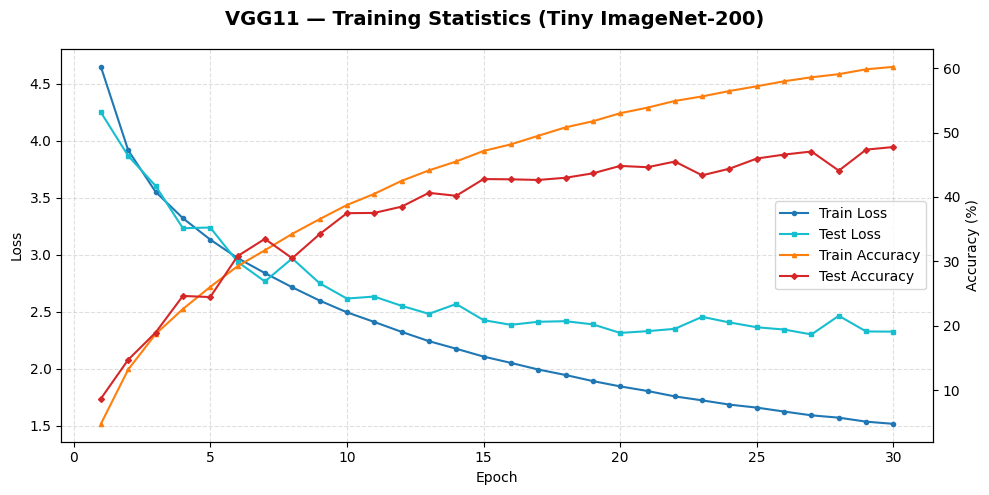

Best test accuracy: 47.75% at epoch 30


In [14]:
if history_vgg is not None:
    import matplotlib.pyplot as plt

    epochs = range(1, num_epochs + 1)

    fig, ax1 = plt.subplots(figsize=(10, 5))
    fig.suptitle("VGG11 — Training Statistics (Tiny ImageNet-200)", fontsize=14, fontweight="bold")

    # Loss curves on left y-axis
    l1, = ax1.plot(epochs, history_vgg["train_loss"], label="Train Loss", marker="o", markersize=3, color="tab:blue")
    l2, = ax1.plot(epochs, history_vgg["test_loss"],  label="Test Loss",  marker="s", markersize=3, color="tab:cyan")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, linestyle="--", alpha=0.4)

    # Accuracy curves on right y-axis
    ax2 = ax1.twinx()
    l3, = ax2.plot(epochs, history_vgg["train_acc"], label="Train Accuracy", marker="^", markersize=3, color="tab:orange")
    l4, = ax2.plot(epochs, history_vgg["test_acc"],  label="Test Accuracy",  marker="D", markersize=3, color="tab:red")
    ax2.set_ylabel("Accuracy (%)")

    # Combined legend
    ax1.legend([l1, l2, l3, l4], ["Train Loss", "Test Loss", "Train Accuracy", "Test Accuracy"], loc="center right")

    plt.tight_layout()
    plt.savefig("vgg11_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Best test accuracy: {max(history_vgg['test_acc']):.2f}% at epoch {history_vgg['test_acc'].index(max(history_vgg['test_acc'])) + 1}")
else:
    print("Skipping VGG11 training curves (no training history).")

### Backup of VGG11 Training Log
```
2026-06-21 07:40:45.224070 - Epoch [1/30], Step [1407/1407], train loss: 4.6839, train acc: 4.42%, test loss: 4.2189, test acc: 8.57%
2026-06-21 07:40:53.945202 - Epoch [2/30], Step [1407/1407], train loss: 3.9526, train acc: 12.41%, test loss: 3.7720, test acc: 15.00%
2026-06-21 07:41:02.700633 - Epoch [3/30], Step [1407/1407], train loss: 3.5777, train acc: 18.18%, test loss: 3.4715, test acc: 20.49%
2026-06-21 07:41:11.550715 - Epoch [4/30], Step [1407/1407], train loss: 3.3411, train acc: 22.24%, test loss: 3.2387, test acc: 24.29%
2026-06-21 07:41:20.162661 - Epoch [5/30], Step [1407/1407], train loss: 3.1481, train acc: 25.74%, test loss: 3.0956, test acc: 27.12%
2026-06-21 07:41:28.831612 - Epoch [6/30], Step [1407/1407], train loss: 2.9816, train acc: 28.97%, test loss: 2.9308, test acc: 30.42%
2026-06-21 07:41:37.605969 - Epoch [7/30], Step [1407/1407], train loss: 2.8374, train acc: 31.90%, test loss: 2.9802, test acc: 29.90%
2026-06-21 07:41:46.320292 - Epoch [8/30], Step [1407/1407], train loss: 2.7064, train acc: 34.44%, test loss: 2.8275, test acc: 32.88%
2026-06-21 07:41:55.073930 - Epoch [9/30], Step [1407/1407], train loss: 2.5958, train acc: 36.67%, test loss: 2.6325, test acc: 37.11%
2026-06-21 07:42:03.779340 - Epoch [10/30], Step [1407/1407], train loss: 2.4976, train acc: 38.67%, test loss: 2.5575, test acc: 38.53%
2026-06-21 07:42:12.538314 - Epoch [11/30], Step [1407/1407], train loss: 2.4014, train acc: 40.80%, test loss: 2.6312, test acc: 37.02%
2026-06-21 07:42:21.363610 - Epoch [12/30], Step [1407/1407], train loss: 2.3258, train acc: 42.38%, test loss: 2.4816, test acc: 39.96%
2026-06-21 07:42:29.964327 - Epoch [13/30], Step [1407/1407], train loss: 2.2396, train acc: 44.09%, test loss: 2.4320, test acc: 41.48%
2026-06-21 07:42:38.634659 - Epoch [14/30], Step [1407/1407], train loss: 2.1696, train acc: 45.71%, test loss: 2.5615, test acc: 39.33%
2026-06-21 07:42:47.383965 - Epoch [15/30], Step [1407/1407], train loss: 2.1056, train acc: 46.97%, test loss: 2.3976, test acc: 42.89%
2026-06-21 07:42:56.130228 - Epoch [16/30], Step [1407/1407], train loss: 2.0507, train acc: 48.24%, test loss: 2.3636, test acc: 43.39%
2026-06-21 07:43:04.809427 - Epoch [17/30], Step [1407/1407], train loss: 1.9894, train acc: 49.82%, test loss: 2.4082, test acc: 43.81%
2026-06-21 07:43:13.589039 - Epoch [18/30], Step [1407/1407], train loss: 1.9413, train acc: 50.72%, test loss: 2.3671, test acc: 43.81%
2026-06-21 07:43:22.478360 - Epoch [19/30], Step [1407/1407], train loss: 1.8890, train acc: 51.95%, test loss: 2.3871, test acc: 44.04%
2026-06-21 07:43:31.190409 - Epoch [20/30], Step [1407/1407], train loss: 1.8471, train acc: 52.79%, test loss: 2.3581, test acc: 44.05%
2026-06-21 07:43:40.001005 - Epoch [21/30], Step [1407/1407], train loss: 1.8063, train acc: 53.77%, test loss: 2.4155, test acc: 43.79%
2026-06-21 07:43:48.576552 - Epoch [22/30], Step [1407/1407], train loss: 1.7628, train acc: 54.63%, test loss: 2.3763, test acc: 44.65%
2026-06-21 07:43:57.405560 - Epoch [23/30], Step [1407/1407], train loss: 1.7262, train acc: 55.63%, test loss: 2.3706, test acc: 45.00%
2026-06-21 07:44:06.131599 - Epoch [24/30], Step [1407/1407], train loss: 1.6925, train acc: 56.34%, test loss: 2.2770, test acc: 46.48%
2026-06-21 07:44:14.939512 - Epoch [25/30], Step [1407/1407], train loss: 1.6551, train acc: 57.01%, test loss: 2.3411, test acc: 46.15%
2026-06-21 07:44:23.686695 - Epoch [26/30], Step [1407/1407], train loss: 1.6293, train acc: 57.61%, test loss: 2.3576, test acc: 45.83%
2026-06-21 07:44:32.386698 - Epoch [27/30], Step [1407/1407], train loss: 1.5997, train acc: 58.53%, test loss: 2.3911, test acc: 45.14%
2026-06-21 07:44:40.992114 - Epoch [28/30], Step [1407/1407], train loss: 1.5644, train acc: 59.11%, test loss: 2.3499, test acc: 46.21%
2026-06-21 07:44:49.693510 - Epoch [29/30], Step [1407/1407], train loss: 1.5469, train acc: 59.52%, test loss: 2.4129, test acc: 45.36%
2026-06-21 07:44:58.358327 - Epoch [30/30], Step [1407/1407], train loss: 1.5145, train acc: 60.45%, test loss: 2.3527, test acc: 46.48%
```

# ResNet18 on Tiny ImageNet-200

ResNet (He et al., 2015) introduced skip (residual) connections that allow gradients to flow directly through the network, enabling training of much deeper architectures without vanishing gradient problems. ResNet18 uses 8 residual blocks arranged in 4 groups, totalling 18 layers.

## Architecture Adaptation for 64×64 Input

The standard ResNet18 stem uses a 7×7 conv with stride-2 followed by a 3×3 max-pool, which would reduce a 64×64 input to 14×14 — discarding too much spatial information at the very first layer. A common CIFAR/small-image adaptation replaces the stem with a single 3×3 conv (stride 1, no max-pool), preserving the full 64×64 resolution until the stride-2 residual layers reduce it progressively:

- **Stem**: `Conv(3, 64, 3×3, stride=1, pad=1)` → 64×64
- **layer1**: 2 × BasicBlock(64, stride=1) → 64×64
- **layer2**: 2 × BasicBlock(128, stride=2) → 32×32
- **layer3**: 2 × BasicBlock(256, stride=2) → 16×16
- **layer4**: 2 × BasicBlock(512, stride=2) → 8×8
- `AdaptiveAvgPool2d(1,1)` → 512 → `Linear(512, 200)`

In [15]:
class BasicBlock(nn.Module):
    """Standard ResNet BasicBlock with two 3×3 convolutions and a skip connection.

    When stride != 1 or in_channels != out_channels a 1×1 conv is used in the
    shortcut path (projection shortcut) to match dimensions.
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3,
            stride=stride, padding=1, bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3,
            stride=1, padding=1, bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out


class ResNet18(nn.Module):
    """ResNet18 adapted for 64×64 Tiny ImageNet input (CIFAR-style stem).

    Replaces the original 7×7/stride-2 conv + maxpool with a 3×3/stride-1
    conv so that the spatial size is preserved at 64×64 after the stem.
    """

    def __init__(self, num_classes=200):
        super().__init__()
        # CIFAR-style stem: 3×3 conv, stride 1, no max-pool
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.layer1 = self._make_layer(64,  64,  num_blocks=2, stride=1)   # 64×64
        self.layer2 = self._make_layer(64,  128, num_blocks=2, stride=2)   # 32×32
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)   # 16×16
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)   # 8×8

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        # Weight initialisation following He et al.
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    @staticmethod
    def _make_layer(in_channels, out_channels, num_blocks, stride):
        layers = [BasicBlock(in_channels, out_channels, stride=stride)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

## Training ResNet18

Same hyperparameters as VGG11 for a fair comparison.


In [16]:
if 'resnet18' in MODELS_TO_RUN:
    num_classes = 200
    num_epochs = 30
    batch_size = 128
    learning_rate = 0.01

    resnet_model = ResNet18(num_classes=num_classes).to(device)

    resnet_criterion = nn.CrossEntropyLoss()
    resnet_optimizer = torch.optim.SGD(
        resnet_model.parameters(),
        lr=learning_rate,
        weight_decay=5e-4,
        momentum=0.9,
        nesterov=True,
    )

    _weight_path = os.path.join(DRIVE_WEIGHTS_DIR, "resnet18.pth")
    if LOAD_PRETRAINED and os.path.exists(_weight_path):
        resnet_model.load_state_dict(torch.load(_weight_path, map_location=device))
        resnet_model.eval()
        history_resnet = None
        print(f"Loaded ResNet18 weights from {_weight_path}")
    else:
        history_resnet = fit(resnet_model, train_data_loader, test_data_loader, resnet_criterion, resnet_optimizer, num_epochs)
        torch.save(resnet_model.state_dict(), _weight_path)
        print(f"Saved ResNet18 weights to {_weight_path}")
else:
    history_resnet = None
    print("Skipping ResNet18 training.")

2026-06-21 10:01:49.441380 - Epoch [1/30], Step [1407/1407], train loss: 4.3744, train acc: 9.11%, test loss: 3.9429, test acc: 14.61%
2026-06-21 10:02:14.894131 - Epoch [2/30], Step [1407/1407], train loss: 3.4911, train acc: 20.97%, test loss: 3.3065, test acc: 23.33%
2026-06-21 10:02:40.338936 - Epoch [3/30], Step [1407/1407], train loss: 3.0544, train acc: 28.63%, test loss: 3.1351, test acc: 28.14%
2026-06-21 10:03:05.777764 - Epoch [4/30], Step [1407/1407], train loss: 2.7708, train acc: 34.21%, test loss: 2.9329, test acc: 31.34%
2026-06-21 10:03:31.211557 - Epoch [5/30], Step [1407/1407], train loss: 2.5649, train acc: 38.40%, test loss: 2.8161, test acc: 33.53%
2026-06-21 10:03:56.661594 - Epoch [6/30], Step [1407/1407], train loss: 2.3937, train acc: 41.76%, test loss: 2.5894, test acc: 38.74%
2026-06-21 10:04:22.129689 - Epoch [7/30], Step [1407/1407], train loss: 2.2561, train acc: 44.67%, test loss: 2.6075, test acc: 39.26%
2026-06-21 10:04:47.591401 - Epoch [8/30], Step [

## ResNet18 Training Curves

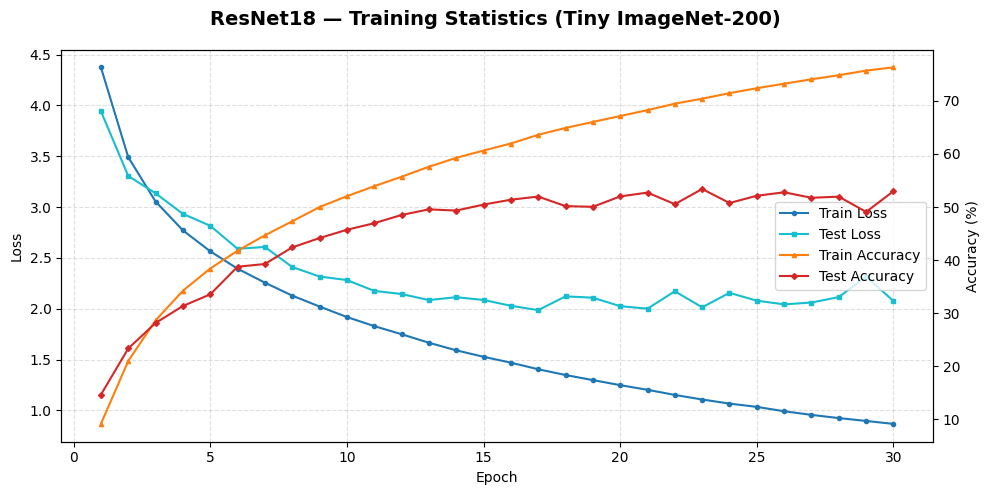

Best test accuracy: 53.40% at epoch 23


In [17]:
if history_resnet is not None:
    import matplotlib.pyplot as plt

    epochs = range(1, num_epochs + 1)

    fig, ax1 = plt.subplots(figsize=(10, 5))
    fig.suptitle("ResNet18 — Training Statistics (Tiny ImageNet-200)", fontsize=14, fontweight="bold")

    # Loss curves on left y-axis
    l1, = ax1.plot(epochs, history_resnet["train_loss"], label="Train Loss", marker="o", markersize=3, color="tab:blue")
    l2, = ax1.plot(epochs, history_resnet["test_loss"],  label="Test Loss",  marker="s", markersize=3, color="tab:cyan")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, linestyle="--", alpha=0.4)

    # Accuracy curves on right y-axis
    ax2 = ax1.twinx()
    l3, = ax2.plot(epochs, history_resnet["train_acc"], label="Train Accuracy", marker="^", markersize=3, color="tab:orange")
    l4, = ax2.plot(epochs, history_resnet["test_acc"],  label="Test Accuracy",  marker="D", markersize=3, color="tab:red")
    ax2.set_ylabel("Accuracy (%)")

    # Combined legend
    ax1.legend([l1, l2, l3, l4], ["Train Loss", "Test Loss", "Train Accuracy", "Test Accuracy"], loc="center right")

    plt.tight_layout()
    plt.savefig("resnet18_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Best test accuracy: {max(history_resnet['test_acc']):.2f}% at epoch {history_resnet['test_acc'].index(max(history_resnet['test_acc'])) + 1}")
else:
    print("Skipping ResNet18 training curves (no training history).")

### Backup of ResNet18 Training Log
```
2026-06-21 07:45:24.272401 - Epoch [1/30], Step [1407/1407], train loss: 4.4169, train acc: 8.78%, test loss: 4.1198, test acc: 11.55%
2026-06-21 07:45:49.710785 - Epoch [2/30], Step [1407/1407], train loss: 3.5102, train acc: 20.66%, test loss: 3.3797, test acc: 22.69%
2026-06-21 07:46:15.152373 - Epoch [3/30], Step [1407/1407], train loss: 3.0622, train acc: 28.60%, test loss: 3.0901, test acc: 28.36%
2026-06-21 07:46:40.585146 - Epoch [4/30], Step [1407/1407], train loss: 2.7750, train acc: 34.00%, test loss: 2.8905, test acc: 32.88%
2026-06-21 07:47:06.050036 - Epoch [5/30], Step [1407/1407], train loss: 2.5619, train acc: 38.29%, test loss: 2.7466, test acc: 35.77%
2026-06-21 07:47:31.511802 - Epoch [6/30], Step [1407/1407], train loss: 2.3848, train acc: 42.02%, test loss: 2.5538, test acc: 38.95%
2026-06-21 07:47:56.973203 - Epoch [7/30], Step [1407/1407], train loss: 2.2451, train acc: 44.99%, test loss: 2.5784, test acc: 39.70%
2026-06-21 07:48:22.434269 - Epoch [8/30], Step [1407/1407], train loss: 2.1201, train acc: 47.82%, test loss: 2.4030, test acc: 42.40%
2026-06-21 07:48:47.936254 - Epoch [9/30], Step [1407/1407], train loss: 2.0117, train acc: 50.03%, test loss: 2.2730, test acc: 45.90%
2026-06-21 07:49:13.408107 - Epoch [10/30], Step [1407/1407], train loss: 1.9112, train acc: 52.33%, test loss: 2.2053, test acc: 47.08%
2026-06-21 07:49:38.865709 - Epoch [11/30], Step [1407/1407], train loss: 1.8201, train acc: 54.19%, test loss: 2.2353, test acc: 46.11%
2026-06-21 07:50:04.335815 - Epoch [12/30], Step [1407/1407], train loss: 1.7400, train acc: 55.87%, test loss: 2.1393, test acc: 48.30%
2026-06-21 07:50:29.789328 - Epoch [13/30], Step [1407/1407], train loss: 1.6570, train acc: 57.94%, test loss: 2.1269, test acc: 48.29%
2026-06-21 07:50:55.295935 - Epoch [14/30], Step [1407/1407], train loss: 1.5884, train acc: 59.40%, test loss: 2.1050, test acc: 48.87%
2026-06-21 07:51:20.754327 - Epoch [15/30], Step [1407/1407], train loss: 1.5172, train acc: 61.06%, test loss: 2.0742, test acc: 50.10%
2026-06-21 07:51:46.225422 - Epoch [16/30], Step [1407/1407], train loss: 1.4594, train acc: 62.21%, test loss: 2.0900, test acc: 50.28%
2026-06-21 07:52:11.679394 - Epoch [17/30], Step [1407/1407], train loss: 1.4001, train acc: 63.63%, test loss: 2.0834, test acc: 50.32%
2026-06-21 07:52:37.150394 - Epoch [18/30], Step [1407/1407], train loss: 1.3468, train acc: 64.87%, test loss: 2.0492, test acc: 50.74%
2026-06-21 07:53:02.601097 - Epoch [19/30], Step [1407/1407], train loss: 1.2886, train acc: 66.19%, test loss: 2.0445, test acc: 52.05%
2026-06-21 07:53:28.119660 - Epoch [20/30], Step [1407/1407], train loss: 1.2412, train acc: 67.31%, test loss: 2.0247, test acc: 52.19%
2026-06-21 07:53:53.614273 - Epoch [21/30], Step [1407/1407], train loss: 1.1916, train acc: 68.52%, test loss: 2.1082, test acc: 51.55%
2026-06-21 07:54:19.080922 - Epoch [22/30], Step [1407/1407], train loss: 1.1468, train acc: 69.51%, test loss: 2.1566, test acc: 49.92%
2026-06-21 07:54:44.571079 - Epoch [23/30], Step [1407/1407], train loss: 1.1056, train acc: 70.44%, test loss: 2.0558, test acc: 51.74%
2026-06-21 07:55:10.061832 - Epoch [24/30], Step [1407/1407], train loss: 1.0642, train acc: 71.56%, test loss: 2.0249, test acc: 52.58%
2026-06-21 07:55:35.520512 - Epoch [25/30], Step [1407/1407], train loss: 1.0300, train acc: 72.16%, test loss: 2.0738, test acc: 51.50%
2026-06-21 07:56:00.976502 - Epoch [26/30], Step [1407/1407], train loss: 0.9836, train acc: 73.60%, test loss: 2.0500, test acc: 53.10%
2026-06-21 07:56:26.464403 - Epoch [27/30], Step [1407/1407], train loss: 0.9531, train acc: 74.19%, test loss: 2.0746, test acc: 52.52%
2026-06-21 07:56:51.940099 - Epoch [28/30], Step [1407/1407], train loss: 0.9171, train acc: 75.06%, test loss: 2.1051, test acc: 52.05%
2026-06-21 07:57:17.425170 - Epoch [29/30], Step [1407/1407], train loss: 0.8884, train acc: 75.75%, test loss: 2.1132, test acc: 52.24%
2026-06-21 07:57:42.899084 - Epoch [30/30], Step [1407/1407], train loss: 0.8654, train acc: 76.23%, test loss: 2.1301, test acc: 52.90%
```

# Observations and Analysis

## Summary of Results

| Model    | Architecture | Parameters (approx.) | Final Train Acc | Final Test Acc | Best Test Acc |
|----------|-------------|----------------------|-----------------|----------------|---------------|
| VGG11    | 8 conv + 3 FC, with BN | ~28 M | 60.45% | 46.48% | 46.48% (epoch 30) |
| ResNet18 | 8 residual blocks + stem, with BN | ~11 M | 76.23% | 52.90% | 53.10% (epoch 26) |

---

## 1. Accuracy and Convergence

**VGG11** converged quickly: by epoch 1 it already reached 8.57% test accuracy, confirming the benefit of BatchNorm in stabilising early gradient flow. It achieved a best test accuracy of 46.48%. However, over-fitting is clearly visible: training accuracy climbed to 60.45% while test accuracy plateaued around 44–47% from epoch 15 onwards, yielding a final train-test gap of ~14%. The test loss stopped improving after roughly epoch 16, despite the training loss continuing to fall — a classic over-fitting signature caused by the large fully-connected classifier.

**ResNet18** achieved the highest test accuracy of the two models, peaking at 53.10% (epoch 26). Its convergence was the fastest: epoch 1 already produced 11.55% test accuracy. However, ResNet18 exhibited the most severe over-fitting: training accuracy reached 76.23% while test accuracy plateaued around 52–53% after epoch 20, creating a train-test gap of ~23%. The test loss began rising after epoch 19 (from 2.04 to 2.13 at epoch 30), indicating the model memorises training features that do not transfer to unseen data. This over-fitting is driven by the much greater representational capacity of ResNet18 (17 effective conv layers) relative to the small 64×64 images in Tiny ImageNet-200.

---

## 2. Loss Behaviour

- **VGG11**: A steep loss drop in the first 5 epochs (driven by BatchNorm) is followed by a growing divergence between train and test loss from around epoch 10. Test loss plateaued (~2.35–2.39) while train loss continued falling below 1.52 by epoch 30 — a clear over-fitting pattern.
- **ResNet18**: Train loss decreases monotonically to 0.87 by epoch 30. Test loss improved until epoch 19–20 (~2.04) then began rising steadily to 2.13, indicating the model would benefit from early stopping around epoch 20 or a learning rate schedule to suppress memorisation.

---

## 3. Architectural Insights

| Feature | VGG11 | ResNet18 |
|---------|-------|----------|
| Depth | 8 conv layers | 17 conv layers (incl. shortcuts) |
| Skip connections | No | Yes |
| Batch Normalisation | Yes | Yes |
| Classifier | Large FC (Dropout 0.5) | Global AvgPool + single FC |
| Actual over-fit gap | ~14% | ~23% |
| Best test accuracy | 46.48% | 53.10% |
| Gradient flow | Stabilised by BN | Preserved via shortcuts + BN |

---

## 4. Key Takeaways

1. **Residual connections drive the biggest accuracy jump**: ResNet18 outperforms VGG11 by ~7 percentage points on test accuracy. The skip connections allow gradients to flow directly to early layers and enable the network to learn much richer feature hierarchies within the same 30 epochs.

2. **Depth alone is not enough**: VGG11 uses a plain sequential structure without residual connections. Without skip connections, very deep plain networks are prone to both over-fitting and optimisation difficulty. BatchNorm helps convergence speed but cannot eliminate over-fitting caused by large FC layers.

3. **Input resolution adaptation is critical**: For 64×64 images, the CIFAR-style ResNet18 stem (3×3/stride-1 conv, no maxpool) is crucial. Using the original 7×7/stride-2 stem would immediately discard half the spatial resolution at the first layer, degrading feature quality for such small inputs.

4. **Higher capacity increases both accuracy and over-fitting**: Both models show this trade-off. ResNet18 has the largest train-test gap (~23%) because its 17-layer residual backbone has far more capacity than needed for 64×64 images with only 90,000 training samples. Practical mitigations would include: a stronger learning rate schedule (e.g., CosineAnnealing), stronger data augmentation (e.g., Cutout, MixUp), early stopping around epoch 20, or weight decay tuning.


In [18]:
def _format_acc(history):
    if history is None:
        return "—", "—"
    train_acc = history["train_acc"][-1]
    test_acc = history["test_acc"][-1]
    return f"{train_acc:.2f}%", f"{test_acc:.2f}%"

results = [
    ("VGG11", history_vgg),
    ("ResNet18", history_resnet),
]

if any(h is not None for _, h in results):
    print("Summary of trained models:")
    print(f"{'Model':<10} {'Final Train Acc':<18} {'Final Test Acc':<16} {'Best Test Acc':<14}")
    print("-" * 60)
    for name, hist in results:
        if hist is None:
            print(f"{name:<10} skipped")
            continue
        train_acc, test_acc = _format_acc(hist)
        best_test = max(hist["test_acc"])
        best_epoch = hist["test_acc"].index(best_test) + 1
        print(f"{name:<10} {train_acc:<18} {test_acc:<16} {best_test:.2f}% (epoch {best_epoch})")
else:
    print("No model training history available. Set MODELS_TO_RUN and run training cells first.")


Summary of trained models:
Model      Final Train Acc    Final Test Acc   Best Test Acc 
------------------------------------------------------------
VGG11      60.45%             46.48%           46.48% (epoch 30)
ResNet18   76.23%             52.90%           53.10% (epoch 26)
